
# Lecture 2b
# 2. Linear Regression: Model Evaluation



## Understanding Evaluation Metrics in Linear Regression

### Basic Concepts:

In linear regression, assessing the accuracy of the model is crucial. Evaluation metrics help in understanding how well the model's predictions align with actual data. Here are some key metrics:

#### 1. Mean Absolute Error (MAE):
- **Definition**: The average of the absolute differences between the predicted and actual values.
- **Formula**: MAE = (1/n) * Σ|yᵢ - ŷᵢ|
- **Interpretation**: Lower MAE values indicate better model performance. It's easy to interpret but does not penalize large errors.

#### 2. Mean Squared Error (MSE):
- **Definition**: The average of the squared differences between the predicted and actual values.
- **Formula**: MSE = (1/n) * Σ(yᵢ - ŷᵢ)²
- **Interpretation**: Lower MSE values are better. It penalizes larger errors more severely than MAE.

#### 3. Root Mean Squared Error (RMSE):
- **Definition**: The square root of the MSE.
- **Formula**: RMSE = √MSE
- **Interpretation**: Provides an error value in the same units as the dependent variable. Like MSE, it emphasizes larger errors more.

#### 4. Mean Absolute Percentage Error (MAPE):
- **Definition**: The average of the absolute percentage errors.
- **Formula**: MAPE = (1/n) * Σ| (yᵢ - ŷᵢ) / yᵢ | * 100%
- **Interpretation**: Expresses accuracy as a percentage, which can be more intuitive. It's useful when comparing across different datasets or models.

### Summary:
- These metrics provide different ways to measure the performance of a linear regression model.
- Choosing the right metric depends on the specific context and requirements of your analysis.


# 2. Linear Regression: Model Evaluation Exercises



### 2.1. Importing data

Q2.1.1. Download the _Staten_Island_housing_market_case.xlsx_ file from Canvas and save it to a folder of your choice. **IMPORTANT! Make sure to save the file under the name "Staten_Island_housing_market_case".**
Q2.1.2 Once the dataset is saved, upload it to your Google Colab files, using the right most _Upload_ button, as shown in the screenshot below:

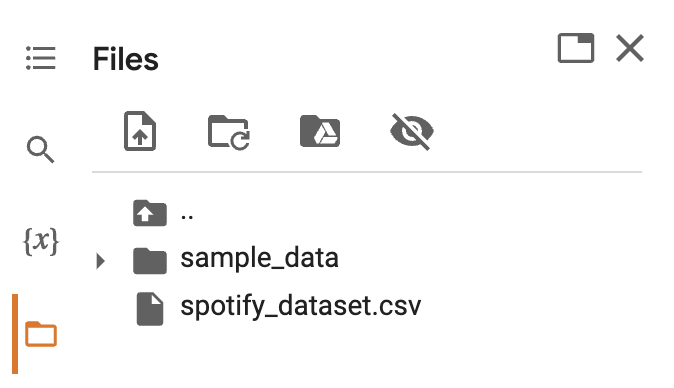



Q2.1.2. Import the pandas and statmodels Python libraries. Import the _Staten_Island_housing_market_case.xlsx_ file, delete the rows with missing values and show the top lines of datafile.

In [1]:
#A.1.2)
import pandas as pd
import os
staten_island_df = pd.read_excel(os.path.join(os.getcwd(), "Staten_Island_housing_market_case.xlsx"))

staten_island_df = staten_island_df.dropna()
staten_island_df.head()

,Sale_id,bbl_id,year,nbhd,bldg_ctgy,tax_cls_p,block,lot,zip,res_unit,...,auth_search,quarter,month,Unemployment_rate,Mortgage_rate,gdp,real_estate_output,days_since_start_datset,days_since_lehman_brothers,days_since_hurricane_sandy
0,82905,553954,2013,ANNADALE,01 ONE FAMILY HOMES,1,5395,4,10312,1,...,True,Q_3,August,7.2,4.4560,15641.3,2782.6,3889,1806,301
1,82906,5539926,2013,ANNADALE,01 ONE FAMILY HOMES,1,5399,26,10312,1,...,True,Q_4,October,7.2,4.1920,15793.9,2782.6,3947,1864,359
2,82907,5540110,2013,ANNADALE,01 ONE FAMILY HOMES,1,5401,10,10312,1,...,True,Q_1,February,7.7,3.5325,15491.9,2782.6,3690,1607,102
3,82916,5620529,2013,ANNADALE,01 ONE FAMILY HOMES,1,6205,29,10312,1,...,True,Q_4,November,6.9,4.2550,15793.9,2782.6,3963,1880,375
4,82922,5621120,2013,ANNADALE,01 ONE FAMILY HOMES,1,6211,20,10312,1,...,True,Q_2,June,7.5,4.0700,15521.6,2782.6,3819,1736,231


Q2.1.3. When evaluating a statistical or machine learning model, it is important to understand how well the model is performing on data it has not seen before. How could we simulate having unseen data?

A2.1.3)
We can simulate having unseen data by splitting the original dataset up in a train and test set.
The train set is then used to train the model on. In this instance that would mean finding the right regression coefficients by fitting it on the train data. The test set is then only used to test the model on.

Q2.1.4. When splitting data into a train and test set, the train set should be much bigger than the test set. (A) Discuss why this is the case. (B) Why is it important to do a random split when splitting the original dataset into a train and test set?

A2.1.4)
(A) The train set should be big enough so that there are enough different cases in the data to learn patterns from.
At the same time, the test set should also be big enough to evaluate on multiple different cases.
Thus: The train set should be bigger than the test set, because the more rows a model can train on, the more robust the model becomes.
There is no exact science for this. Most machine learning practicioners use a 80/20 or 70/30 train/test split.

(B) When splitting up the original dataset into a train and test set, it is important to do so randomly.
This is the case, because the ordering or the original dataset might not be random.
For example, maybe the dataset was sorted on price. By just taking the toop 70% as train set,
you train you regression model on the most expensive houses, while you test on the cheapest houses.
The model learns the patterns to predict expensive houses, but these predictive patterns might be different for cheap houses.
Therefore it is important to do a random split to ensure that all different kind of classes are mixed into both the train and test set.

Q2.1.5. Before splitting the data into a train and test set, you must determine the y and X features. In this case we have already given the names of the features that we would like to use to predict the price, and created a list containing these names (```X_features_list```)? Please create the feature variable X and the dependent variable y. 

In [2]:
#A2.1.5)
X_features_list = ['land_sqft' , 'tot_sqft', 'yr_built' , 'sale_date' , 'long' , 'lat' , 'atm' , 'bank' , 'bar' ,
                   'book_store' , 'bus_station' , 'cafe' , 'church' , 'city_hall' , 'doctor', 'fire_station' ,
                   'gas_station' , 'gym' , 'hospital' , 'library' , 'lodging', 'mosque',
                   'movie_theater' , 'museum' , 'night_club', 'park' , 'parking' , 'police',
                   'restaurant', 'school', 'shopping_mall', 'store', 'supermarket', 'train_station']

X = staten_island_df[X_features_list]  # Features (all columns except the target)
y = staten_island_df['price']  # Target variable

 Now that we've created the y and X variables, let's split them up in dependent (y) and independent (X) train and test features. We do this by using the sklearn function train_test_split:

In [3]:
from sklearn.model_selection import train_test_split

Q2.1.6) Use the train_test_split() function from the Sklearn library to split the data into a train and test set with a 80/20 division. Name the train and the test sets: X_train, X_test, y_train, y_test. To make sure that everybody has the same results, add the parameter random_state=1 to your train_test_split command. For more information about this see here: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html.

In [4]:
#A2.1.6) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

 Now that we created a train and test set, we can train a multivariate regression model on the train set. In order to do this we will import the statsmodels library. 

In [5]:
import statsmodels.api as sm

Q2.1.7) Look at the regression table and answer the following question: there is a new restaurant being built within 500m meters of a Staten Island home. According to this model, will this leads to an increase or decrease in property value?

In [6]:
# Adding the constant term for the intercept
X_train = sm.add_constant(X_train)

# Fitting the model
multivar_linreg = sm.OLS(y_train, X_train).fit()

# Printing the summary of the model
print(multivar_linreg.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.471
Model:                            OLS   Adj. R-squared:                  0.471
Method:                 Least Squares   F-statistic:                     1002.
Date:                Thu, 07 Dec 2023   Prob (F-statistic):               0.00
Time:                        09:05:32   Log-Likelihood:            -5.0432e+05
No. Observations:               38308   AIC:                         1.009e+06
Df Residuals:                   38273   BIC:                         1.009e+06
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          4.489e+07   2.42e+06     18.513

A2.1.7)
The coefficient for ```restaurant``` is 1745. This means that for every extra restaurant, the price of a house goes up by 1745 dollars, all else being equal. It's important to realize that this is a correlation, not a causation.

Q2.1.8. Now that regression model has been trained on the train set, let's evaluate it's performance. To evaluate, we first need to know the predictions of the trained regression model. Create a pandas dataframe called ```train_evaluation_df```, add the y_train values to a newly created column in that dataframe and name that column ```price```. Finally, use the predict function on the previously created model ```multivar_linreg``` and X_train to predict prices based on X_train. Add these values to a new column called ```predicted_price``` in the train_evaluation dataframe.

In [7]:
# A2.1.8)
train_evaluation_df = pd.DataFrame()
train_evaluation_df['price'] = y_train
train_evaluation_df['predicted_price'] = multivar_linreg.predict(X_train)
train_evaluation_df

,price,predicted_price
9974,480000.0,386067.594147
32628,165500.0,225412.837178
46143,885000.0,718125.377893
19401,424000.0,324350.062296
9138,423000.0,407491.135626
...,...,...
43738,339000.0,324946.171615
32526,200000.0,292758.280634
5207,137000.0,341853.711233
12187,240216.0,304606.242073


Q2.1.9. When evaluating a regression model, you want to know how much the model's predicted price is off from the real price. This difference is called the 'error'. Let's create a new column, called 'error' and sort the values to answer the following questions: (A) What is the biggest prediction error caused by the model? (B) To what extent does that tell you how well the regression model is performing?

In [8]:
# in order to have Python show large numbers not in scientific notation, we run the following command (you don't need to know this for your exam):
pd.set_option('display.float_format', '{:.2f}'.format)

In [9]:
train_evaluation_df['error'] = train_evaluation_df['price'] - train_evaluation_df['predicted_price']
train_evaluation_df['error'].sort_values()

44238   -868517.58
8103    -835939.78
34455   -794014.30
41333   -788718.99
3165    -764675.13
           ...    
20350   1019842.83
40979   1049151.89
34838   1133114.32
8122    1165641.17
7631    1209126.77
Name: error, Length: 38308, dtype: float64

A2.1.9)
(A) 1209126.77 is the biggest error made by the model. For this house, the model is thus off by more than a million dollars.

(B) This does not tell us anything about the overall performance of the model. This one bad prediction might be an exception to the rule. In order to understand overall performance, we need to understand the distribution of errors.


Let's create a visualisation of a subset of the sorted errors of the model by running the code below. We do this by making use of the library matplotlib.

In [10]:
from matplotlib import pyplot as plt

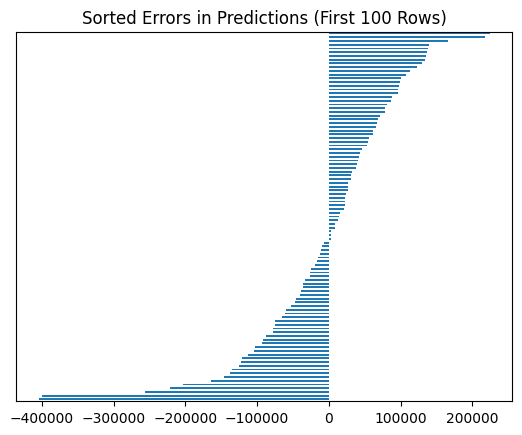

In [11]:
# Sorting and plotting the errors
train_evaluation_df_subset = train_evaluation_df.iloc[1:100,:]
train_evaluation_df_subset['error'].sort_values().plot(kind='barh')

# Removing the y-axis labels (indexes)
plt.yticks([])

plt.title('Sorted Errors in Predictions (First 100 Rows)')

plt.show()


Q2.1.10. To What extent does this give a better overview of the performance of the model?

A2.1.10)
This does give a better feeling for the performance of the model, as it shows that for some rows the model is off by a lot
while for other houses the prediction if very close to the real price.

Q2.1.11. Visualizing the distribution of errors gives some insight into the performance of the model. But ideally, we want to calculate a single number that tracks performance. This will make it easier to compare different configurations of the same model and to compare performance on train and test set. This single number to evaluate performance is called an 'evaluation metric'. There are multiple evaluation metrics for regression. We will start with Mean Absolute Error. This is an intuitive metric that tracks the average of all absolute errors. Taking the absolute just means taking the positive version of any number. For example, the absolute of -5 is 5, while the absolute of 5 is also 5. Taking the absolute is done to make sure that all values that you're comparing are positive. First calculate the absolute error and insert it into a new column in train_evaluation_df called 'absolute_error'.

For this, we make use of the numpy function ```abs``` that calculates absolute values. See here for more information: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.abs.html

In [12]:
#A.2.1.11)
train_evaluation_df['absolute_error'] = train_evaluation_df['error'].abs()
train_evaluation_df

,price,predicted_price,error,absolute_error
9974,480000.00,386067.59,93932.41,93932.41
32628,165500.00,225412.84,-59912.84,59912.84
46143,885000.00,718125.38,166874.62,166874.62
19401,424000.00,324350.06,99649.94,99649.94
9138,423000.00,407491.14,15508.86,15508.86
...,...,...,...,...
43738,339000.00,324946.17,14053.83,14053.83
32526,200000.00,292758.28,-92758.28,92758.28
5207,137000.00,341853.71,-204853.71,204853.71
12187,240216.00,304606.24,-64390.24,64390.24


Q2.1.12. Now that we've calculated the absolute errors, we can take the mean to calculate the Mean Absolute Error (MAE). (A) How high is the mean? (B) How would you interpret this number? Do you think it's high or low?

In [13]:
#A.2.1.12)
MAE = train_evaluation_df['absolute_error'].mean()
MAE
# (A) 88051
# (B) A MAE or 88051 means that on average the regression if off by 88051 dollars per house.
# This number is relatively high for practical applications.

88051.31759912937

Q2.1.13. While MAE is easy to interpret, it's downside is that it treats high and low errors in the same way. That's why the Mean Squared Error (MSE) is next. The MSE does punish bigger errors, by squaring them. Calculate the squared errors and insert it into the 'mean_squared_error' column. (A) What is the MSE? (B) To what extent are you able to interpret the MSE? (C) Can you explain why MSE "punishes" high errors harder than MAE?

In [14]:
#A.2.1.13)

train_evaluation_df['squared_error'] = train_evaluation_df['error']**2
MSE = train_evaluation_df['squared_error'].mean()
print("The Mean Squared Error:", MSE)
train_evaluation_df

# ANSWERS:

# (A) The MSE is '15936682515'.
# (B) The MSE is less intuitive to interpret.
# Lower is better, but since it is a squared number it often gets really big and does not directly translate to interpretable numbers.
# (C) MSE "punishes" larger errors more than MAE because it squares the errors, exponentially increasing their impact.
#  MAE treats all errors linearly, giving equal weight to small and large errors. A MAE of an error of 2 is 2, while a MSE of an error of 2 is 4.
# The bigger the error, the bigger the MSE. Lower MSE is better, so MSE punishes bigger errors.


The Mean Squared Error: 15936682515.60244


,price,predicted_price,error,absolute_error,squared_error
9974,480000.00,386067.59,93932.41,93932.41,8823296869.30
32628,165500.00,225412.84,-59912.84,59912.84,3589548058.71
46143,885000.00,718125.38,166874.62,166874.62,27847139503.44
19401,424000.00,324350.06,99649.94,99649.94,9930110084.33
9138,423000.00,407491.14,15508.86,15508.86,240524874.16
...,...,...,...,...,...
43738,339000.00,324946.17,14053.83,14053.83,197510092.27
32526,200000.00,292758.28,-92758.28,92758.28,8604098626.20
5207,137000.00,341853.71,-204853.71,204853.71,41965043005.81
12187,240216.00,304606.24,-64390.24,64390.24,4146103274.21


Q2.1.14. Mean Squared Error (MSE) is great at giving bigger errors more weight than MAE, but it can be a bit tricky to understand. That's why we turn to Root Mean Squared Error (RMSE) next. RMSE has the best of both worlds: it's easy to get what it's telling you and it still focuses on the bigger errors. It's pretty much just the MSE with an extra step - you take the square root of the MSE, which puts it back in the same units as your original data. Calculate the RMSE. (A) What is the RMSE number?

In [15]:
#A.2.1.14)

RMSE = (train_evaluation_df['squared_error']).mean()**0.5

print("The Root Mean Squared Error:", RMSE)

# THE RMSE is 126241.

The Root Mean Squared Error: 126240.57396733604


Q2.1.15. After exploring Mean Absolute Error (MAE), Mean Squared Error (MSE) and Root Mean Squared Error (RMSE), we turn our attention to another important metric: Mean Absolute Percentage Error (MAPE). Unique in its approach, MAPE measures the error as a percentage of the actual values, making it useful for problems where the relative size of the error is more important than the absolute size. First calculate the percentage error and insert it into the 'percentage_error' column. Secondly, calculate the absolute percentage error and insert it in the 'absolute_percentage_error' column. Finally, calculate the MAPE by averaging the absolute_percentage_error. (A) What is the MAPE and how should this number be interpreted?

In [16]:
# A2.1.15)
train_evaluation_df['percentage_error'] = train_evaluation_df['error'] / train_evaluation_df['price'] * 100
train_evaluation_df['absolute_percentage_error'] = train_evaluation_df['percentage_error'].abs()
MAPE = train_evaluation_df['absolute_percentage_error'].mean()
print("The Mean Absolute Percentage Error:", MAPE)
train_evaluation_df

# ANSWERS:

# (A) The MAPE is "39.01". This means that the regression model is off by 39% on average. This is quite a high number for practical applications.

The Mean Absolute Percentage Error: 38.90981745620614


,price,predicted_price,error,absolute_error,squared_error,percentage_error,absolute_percentage_error
9974,480000.00,386067.59,93932.41,93932.41,8823296869.30,19.57,19.57
32628,165500.00,225412.84,-59912.84,59912.84,3589548058.71,-36.20,36.20
46143,885000.00,718125.38,166874.62,166874.62,27847139503.44,18.86,18.86
19401,424000.00,324350.06,99649.94,99649.94,9930110084.33,23.50,23.50
9138,423000.00,407491.14,15508.86,15508.86,240524874.16,3.67,3.67
...,...,...,...,...,...,...,...
43738,339000.00,324946.17,14053.83,14053.83,197510092.27,4.15,4.15
32526,200000.00,292758.28,-92758.28,92758.28,8604098626.20,-46.38,46.38
5207,137000.00,341853.71,-204853.71,204853.71,41965043005.81,-149.53,149.53
12187,240216.00,304606.24,-64390.24,64390.24,4146103274.21,-26.81,26.81


## K-Nearest Neighbors (KNN) Classification Evaluation Metrics Theory

### Basic Concepts:

Evaluating the performance of a KNN classifier is critical for understanding its effectiveness in classification tasks. Key metrics used include Accuracy, Precision, and Recall, each with its unique strengths and limitations.

#### 1. Accuracy:
- **Definition**: Proportion of total correct predictions (both positive and negative) relative to all predictions.
- **Formula**: Accuracy = (True Positives + True Negatives) / Total Observations
- **Pros**:
  - Simple and intuitive: Provides a quick snapshot of the model's overall effectiveness.
  - Widely used and understood in many domains.
- **Cons**:
  - Can be misleading in imbalanced datasets where one class dominates.
  - Doesn't distinguish between types of errors (false positives and false negatives).

#### 2. Precision:
- **Definition**: Proportion of correctly predicted positive observations out of all predicted positive observations.
- **Formula**: Precision = True Positives / (True Positives + False Positives)
- **Pros**:
  - Crucial when the cost of false positives is high.
  - Helps to understand the model's ability to avoid labeling negative samples as positive.
- **Cons**:
  - Doesn't consider false negatives; not useful when the focus is on minimizing missed positive cases.
  - Can give a skewed view of the model's performance if the dataset is imbalanced.

#### 3. Recall (Sensitivity):
- **Definition**: Proportion of correctly predicted positive observations to all observations in the actual class.
- **Formula**: Recall = True Positives / (True Positives + False Negatives)
- **Pros**:
  - Vital when the cost of false negatives is high.
  - Indicates the model's capability to detect positive cases.
- **Cons**:
  - Doesn't account for false positives; a model can have high recall by predicting many observations as positive.
  - May not provide a complete picture of the model's performance, especially in the presence of imbalanced classes.

### Summary:
- **Accuracy** is best used when the classes are balanced and the costs of false positives and false negatives are roughly equivalent.
- **Precision** is ideal in situations where false positives are more costly than false negatives.
- **Recall** is crucial in scenarios where false negatives carry a higher cost than false positives.
- In practice, often a balance between Precision and Recall is sought, and metrics like the F1-Score are used to find a harmonious balance between the two.


## 3. KNN: Model Evaluation Exercises

Now that we understand the how to evaluate regression, let's continue with KNN model evaluation. Let's first train a model like we did in previous seminar, but now with all numerical features instead of just total square feet and price.

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

# Exclude three family homes from the dataset
staten_island_df = staten_island_df[staten_island_df.bldg_ctgy != '03  THREE FAMILY HOMES']

# Assuming staten_island_df is your DataFrame
y = staten_island_df['bldg_ctgy']  # Target variable

X_features_list = ['land_sqft', 'tot_sqft', 'yr_built', 'sale_date', 'long', 'lat', 'atm', 'bank', 'bar',
                   'book_store', 'bus_station', 'cafe', 'church', 'city_hall', 'doctor', 'fire_station',
                   'gas_station', 'gym', 'hospital', 'library', 'lodging', 'mosque',
                   'movie_theater', 'museum', 'night_club', 'park', 'parking', 'police',
                   'restaurant', 'school', 'shopping_mall', 'store', 'supermarket', 'train_station']

X = staten_island_df[X_features_list]  # Features (all columns except the target)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 1)

# Normalizing the feature data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training the KNN model
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train_scaled, y_train)

# Predicting and evaluating the model on the train data
y_pred_train = knn.predict(X_train_scaled)
conf_matrix = confusion_matrix(y_train, y_pred_train)

unique_classes = sorted(set(y_test))
conf_matrix_df = pd.DataFrame(conf_matrix, index=unique_classes, columns=unique_classes)

# Renaming the index and columns for clarity
conf_matrix_df.index.name = 'Actual'
conf_matrix_df.columns.name = 'Predicted'

print(conf_matrix_df)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/joblib/externals/loky/backend/context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[Errno 2] No such file or directory: 'sysctl'
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/joblib/externals/loky/backend/context.py", line 270, in _count_physical_cores
    cpu_info = subprocess.run(
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "/Library/Frameworks/Python.framework/Version

Predicted             01  ONE FAMILY HOMES  02  TWO FAMILY HOMES
Actual                                                          
01  ONE FAMILY HOMES                 26825                   717
02  TWO FAMILY HOMES                  4134                  6256


Q3.1) Looking at the confusion matrix above, answer the following questions:
- (A) What are the True Positives?
- (B) What are the True Negatives?
- (C) What are the False Positives?
- (D) What are the False Negatives?

- Hint: take '01 ONE FAMILY HOMES' as being the 'true' class.

A3.1)
True Positives (TP) for "01 ONE FAMILY HOMES": 26825 (correctly predicted as "01 ONE FAMILY HOMES").

False Negatives (FN) for "01 ONE FAMILY HOMES": 717 (incorrectly predicted as "02 TWO FAMILY HOMES").

False Positives (FP) for "01 ONE FAMILY HOMES": 4134 (incorrectly predicted as "01 ONE FAMILY HOMES" but actually "02 TWO FAMILY HOMES").

True Negatives (TN) for "01 ONE FAMILY HOMES": 6256 (correctly predicted as "02 TWO FAMILY HOMES").

Q3.2) Now that we have the TP, FN, FP and TN, we can start calculating the first evaluation metric: accuracy. Accuracy is the proportion of total correct predictions (both positive and negative) relative to all predictions. Accuracy = (True Positives + True Negatives) / Total Observations. Calculate the accuracy for this KNN model on the train set. (A) Reflect on this number, is it high or low? (B) What are the pro's and cons of using accuracy for evaluation?

In [18]:
#A3.2)
TP = 26825  # True Positives for "01 ONE FAMILY HOMES"
TN = 6256   # True Negatives (which is TP for "02 TWO FAMILY HOMES")
Total = 26825 + 717 + 4134 + 6256  # Sum of all elements in the confusion matrix

accuracy = (TP + TN) / Total

accuracy

#(A) The accuracy is quite OK, I would consider it to be high
#(B) The pro is that you get one measure that everyone immediately gets, the con is that it can be misleading, especially in cases when you try to predict a rare event.


0.872113255298956

Q3.3) Precision is often preferred over accuracy in scenarios where the cost of false positives is high. It helps to understand the model's ability to avoid labeling negative samples as positive. Formula: Precision = True Positives / (True Positives + False Positives). Calculate the precision for this KNN model on the train set. (A) Reflect on this number. To what extent does it change your opinion of the model when comparing it to the accuracy?

In [19]:
# A3.3)
# Calculating precision for "01 ONE FAMILY HOMES"
TP = 26825  # True Positives for "01 ONE FAMILY HOMES"
FP = 4134   # False Positives for "01 ONE FAMILY HOMES"

precision = TP / (TP + FP)
precision

# It still not bad. It does not really change my opinion of the model.

0.866468555185891

Q3.4) Recall is emphasized over accuracy or precision in situations where missing a positive instance (false negatives) is more critical than incorrectly labeling negative instances as positive (false positives). It measures the model's ability to capture all relevant instances, which is vital in contexts where failing to detect a positive case has serious consequences. Formula: Recall = True Positives / (True Positives + False Negatives). Calculate the recall for this KNN model on the train set. (A) Reflect on this number. Which evaluation metric do you find more important for this problem? Accuracy, precision or recall? Explain why.

In [20]:
#A3.4)
# Calculating recall for "01 ONE FAMILY HOMES"
TP = 26825  # True Positives for "01 ONE FAMILY HOMES"
FN = 717    # False Negatives for "01 ONE FAMILY HOMES"

recall = TP / (TP + FN)
recall

# It is always important to use various metrics to evaluate a model, it depends on the purpose. I would say in this case that I don't prefer a 
# false negative over a false positive, so I would stick with accuracy in the case I could only use one.

0.9739670321690509